In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)

os.makedirs('../outputs/output_graphs', exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# ---------------- Step: Load Data ----------------
df = pd.read_csv(
    '../data/raw/Crimes_-_2001_to_Present_20260902.csv'
)

print("Shape:", df.shape)
print(df.head())

Shape: (759290, 22)
         ID Case Number                    Date                  Block  IUCR  \
0  14070466    JJ540292  12/31/2025 02:30:00 PM       001XX W 112TH PL  0910   
1  14070469    JJ540385  12/31/2025 02:30:00 PM  048XX S LAKE PARK AVE  0560   
2  14070549    JJ540301  12/31/2025 02:30:00 PM       106XX S AVENUE M  0486   
3  14078959    JK109689  12/31/2025 02:30:00 PM  038XX S VINCENNES AVE  0820   
4  14070546    JJ540340  12/31/2025 02:24:00 PM   010XX S MICHIGAN AVE  1330   

          Primary Type              Description Location Description  Arrest  \
0  MOTOR VEHICLE THEFT               AUTOMOBILE               STREET   False   
1              ASSAULT                   SIMPLE               STREET   False   
2              BATTERY  DOMESTIC BATTERY SIMPLE            APARTMENT   False   
3                THEFT           $500 AND UNDER            APARTMENT   False   
4    CRIMINAL TRESPASS                  TO LAND            APARTMENT    True   

   Domestic  Beat 

In [6]:
# ---------------- Step: Data Structure ----------------

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 759290 entries, 0 to 759289
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    759290 non-null  int64  
 1   Case Number           759290 non-null  str    
 2   Date                  759290 non-null  str    
 3   Block                 759290 non-null  str    
 4   IUCR                  759290 non-null  str    
 5   Primary Type          759290 non-null  str    
 6   Description           759290 non-null  str    
 7   Location Description  755423 non-null  str    
 8   Arrest                759290 non-null  bool   
 9   Domestic              759290 non-null  bool   
 10  Beat                  759290 non-null  int64  
 11  District              759290 non-null  int64  
 12  Ward                  759286 non-null  float64
 13  Community Area        759255 non-null  float64
 14  FBI Code              759290 non-null  str    
 15  X Coordinat

In [7]:
# ---------------- Step: Data Structure ----------------

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 759290 entries, 0 to 759289
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    759290 non-null  int64  
 1   Case Number           759290 non-null  str    
 2   Date                  759290 non-null  str    
 3   Block                 759290 non-null  str    
 4   IUCR                  759290 non-null  str    
 5   Primary Type          759290 non-null  str    
 6   Description           759290 non-null  str    
 7   Location Description  755423 non-null  str    
 8   Arrest                759290 non-null  bool   
 9   Domestic              759290 non-null  bool   
 10  Beat                  759290 non-null  int64  
 11  District              759290 non-null  int64  
 12  Ward                  759286 non-null  float64
 13  Community Area        759255 non-null  float64
 14  FBI Code              759290 non-null  str    
 15  X Coordinat

In [8]:
# ---------------- Step: Missing Values ----------------

missing = df.isna().sum()

missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

print(
    missing_df[
        missing_df['missing_count'] > 0
    ].sort_values(
        'missing_pct',
        ascending=False
    )
)

                      missing_count  missing_pct
X Coordinate                   5412         0.71
Y Coordinate                   5412         0.71
Latitude                       5412         0.71
Longitude                      5412         0.71
Location                       5412         0.71
Location Description           3867         0.51
Ward                              4         0.00
Community Area                   35         0.00


In [9]:
# ---------------- Step: Duplicates ----------------

print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate Case Numbers:",
    df['Case Number'].duplicated().sum()
)

Duplicate rows: 0
Duplicate Case Numbers: 74


In [10]:
# ---------------- Step: Date/Time Features ----------------

df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()

print(
    "Date range:",
    df['Date'].min(),
    "to",
    df['Date'].max()
)

Date range: 2023-01-01 14:36:00 to 2025-12-31 14:30:00


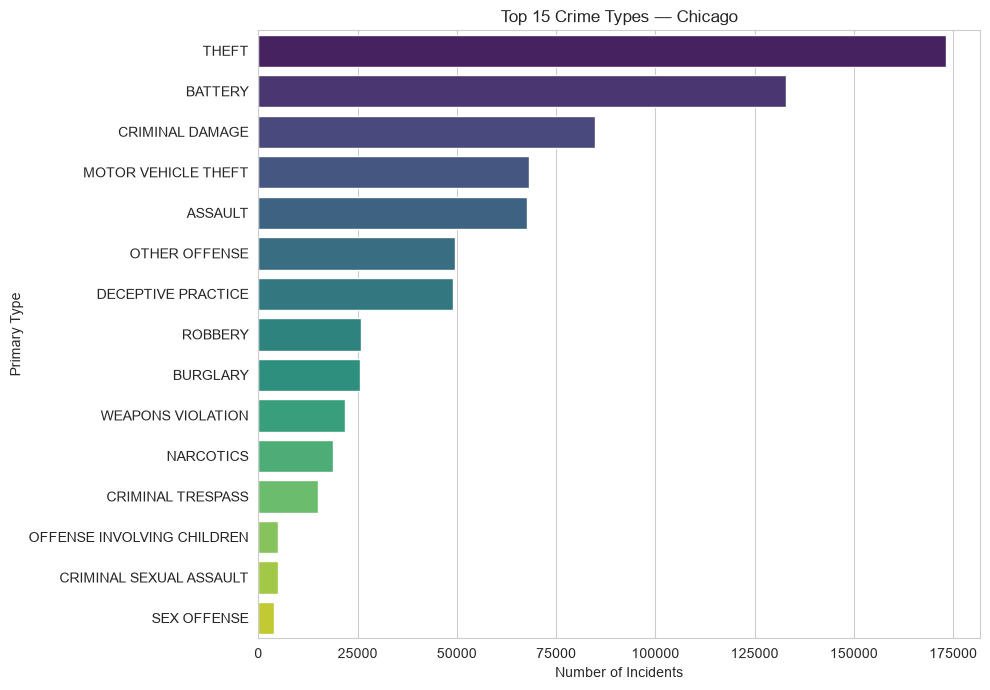

In [11]:
# ---------------- Graph 1: Top 15 Crime Types ----------------

top_crimes = df['Primary Type'].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_crimes.values,
    y=top_crimes.index,
    hue=top_crimes.index,
    palette='viridis'
)

plt.title('Top 15 Crime Types — Chicago')
plt.xlabel('Number of Incidents')

plt.legend([], [], frameon=False)

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/01_top_crimes.png',
    dpi=300
)

plt.show()

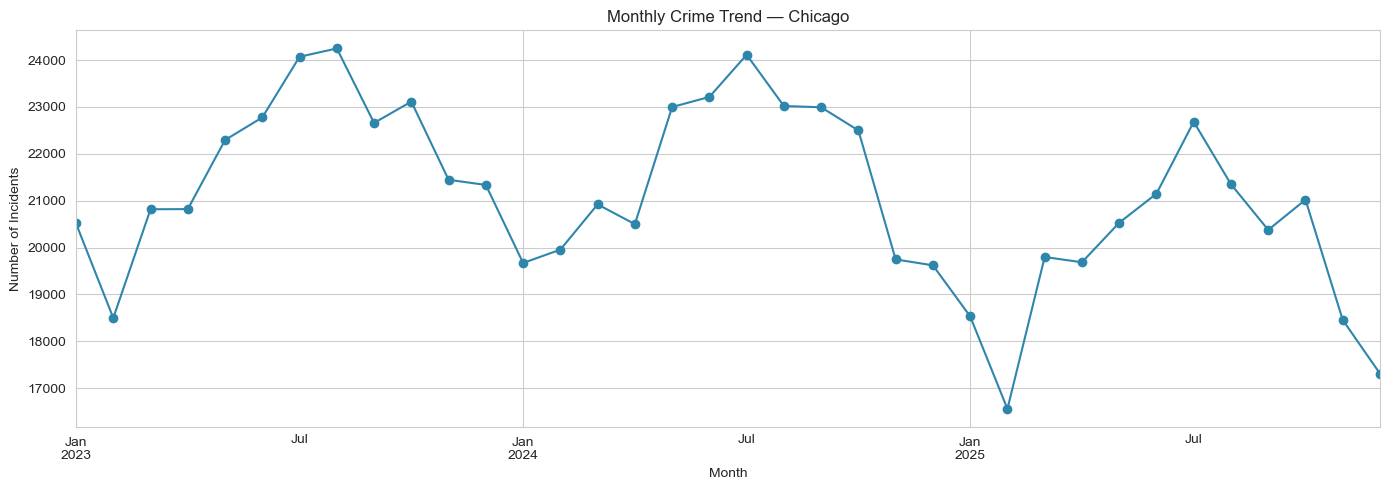

In [ ]:

# ---------------- Graph 2: Monthly Crime Trend ----------------

monthly = df.groupby(
    df['Date'].dt.to_period('M')
).size()

plt.figure(figsize=(14, 5))

monthly.plot(
    kind='line',
    marker='o',
    color='#2E86AB'
)

plt.title('Monthly Crime Trend — Chicago')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/02_monthly_trend.png',
    dpi=300
)


plt.show()

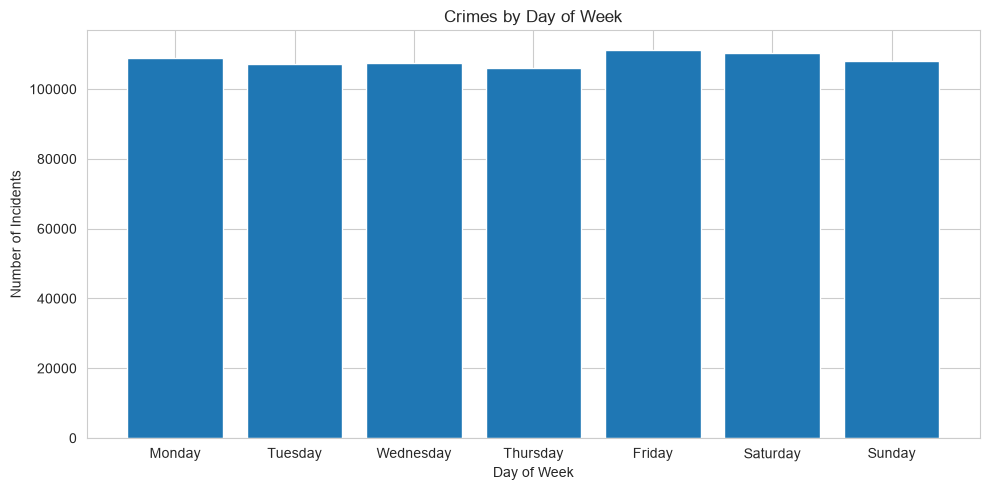

In [12]:
# ---------------- Graph 3: Crimes by Day of Week ----------------

order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

dow_counts = df['DayOfWeek'].value_counts().reindex(order)

plt.figure(figsize=(10, 5))

plt.bar(
    dow_counts.index,
    dow_counts.values
)

plt.title('Crimes by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/03_day_of_week.png',
    dpi=300
)

plt.show()

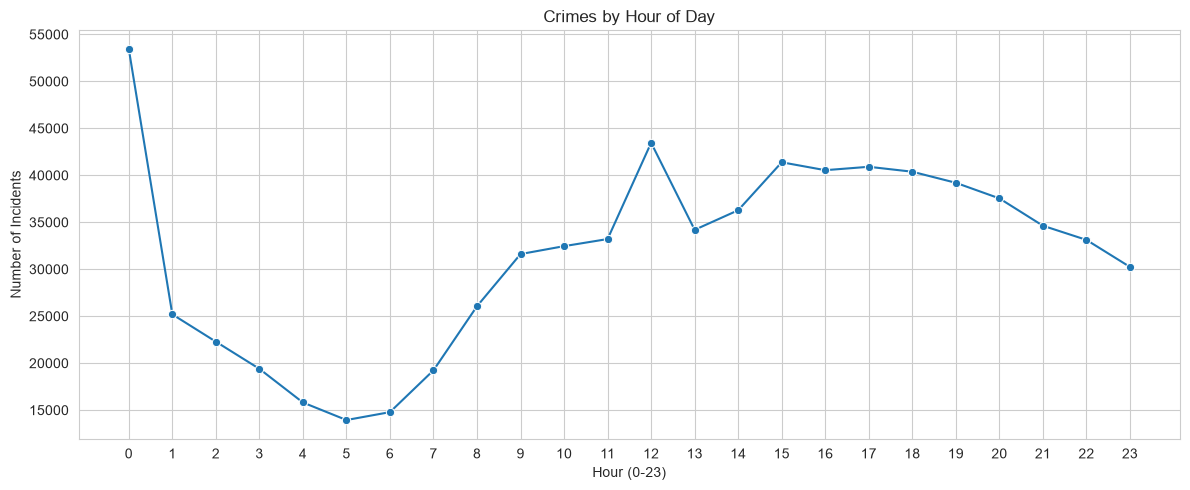

In [13]:
# ---------------- Graph 4: Crimes by Hour of Day ----------------

hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hour_counts.index,
    y=hour_counts.values,
    marker='o'
)

plt.title('Crimes by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Incidents')

plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/04_hour_of_day.png',
    dpi=300
)

plt.show()

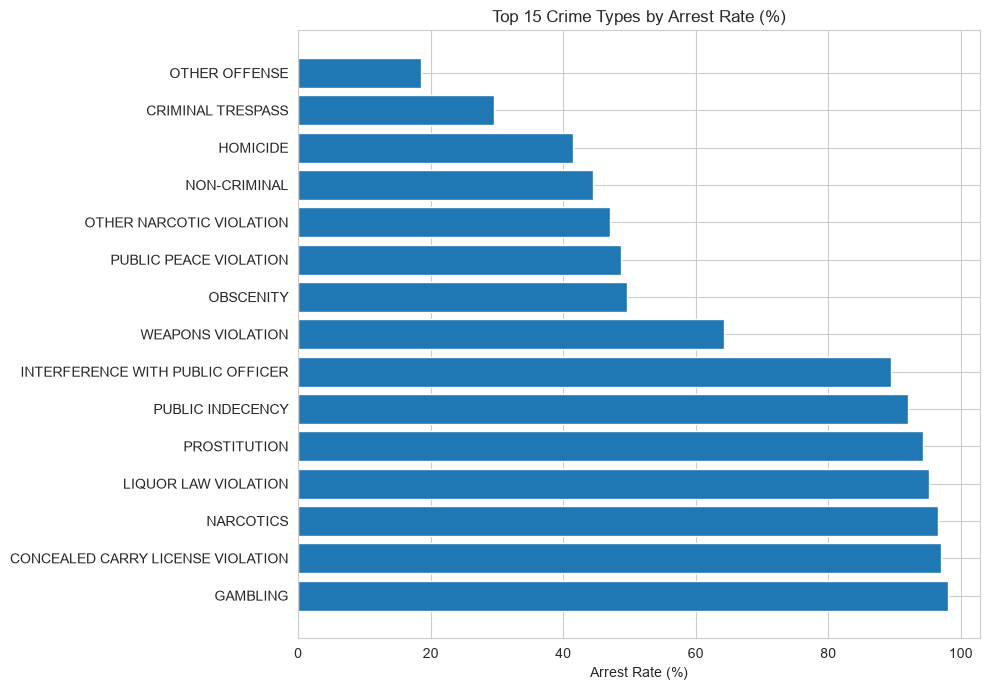

In [14]:
# ---------------- Graph 5: Arrest Rate by Crime Type ----------------

arrest_by_crime = (
    df.groupby('Primary Type')['Arrest']
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)

plt.figure(figsize=(10, 7))

plt.barh(
    arrest_by_crime.index,
    arrest_by_crime.values
)

plt.title('Top 15 Crime Types by Arrest Rate (%)')
plt.xlabel('Arrest Rate (%)')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/05_arrest_rate.png',
    dpi=300
)

plt.show()

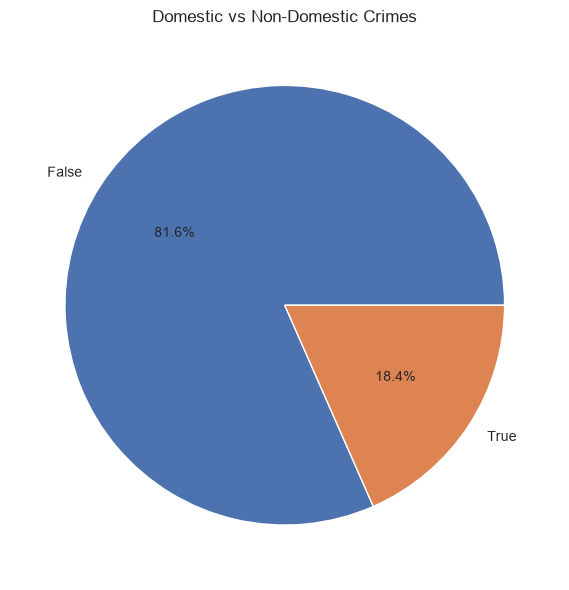

In [15]:
# ---------------- Graph 6: Domestic vs Non-Domestic ----------------

plt.figure(figsize=(6, 6))

df['Domestic'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452']
)

plt.title('Domestic vs Non-Domestic Crimes')
plt.ylabel('')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/06_domestic_pie.png',
    dpi=300
)

plt.show()

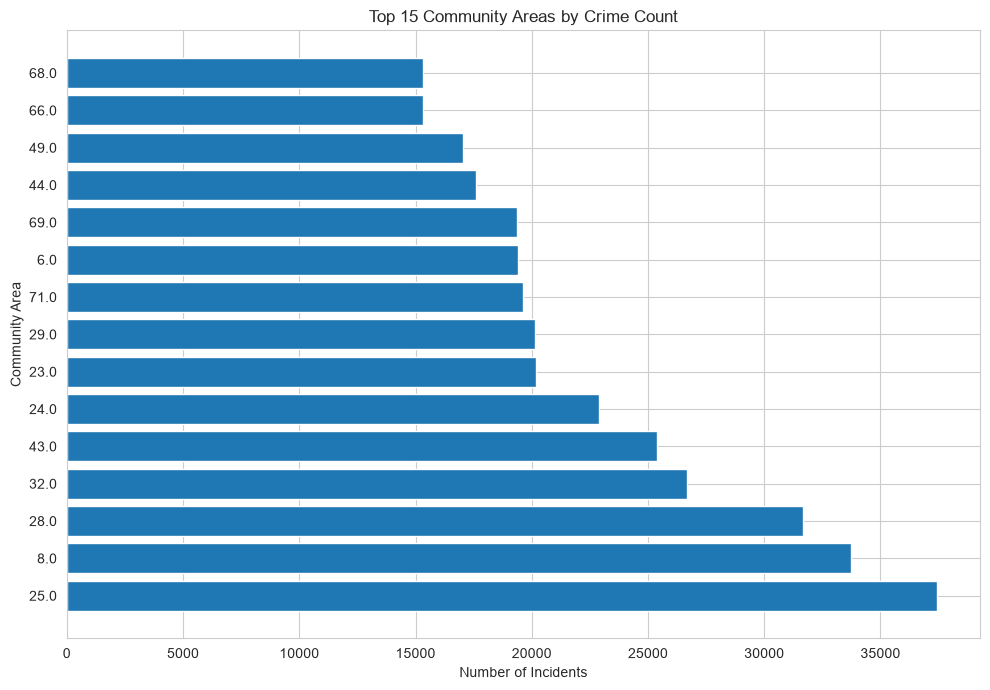

In [16]:
# ---------------- Graph 7: Top Community Areas ----------------

top_areas = df['Community Area'].value_counts().head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_areas.index.astype(str),
    top_areas.values
)

plt.title('Top 15 Community Areas by Crime Count')
plt.xlabel('Number of Incidents')
plt.ylabel('Community Area')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/07_top_areas.png',
    dpi=300
)

plt.show()

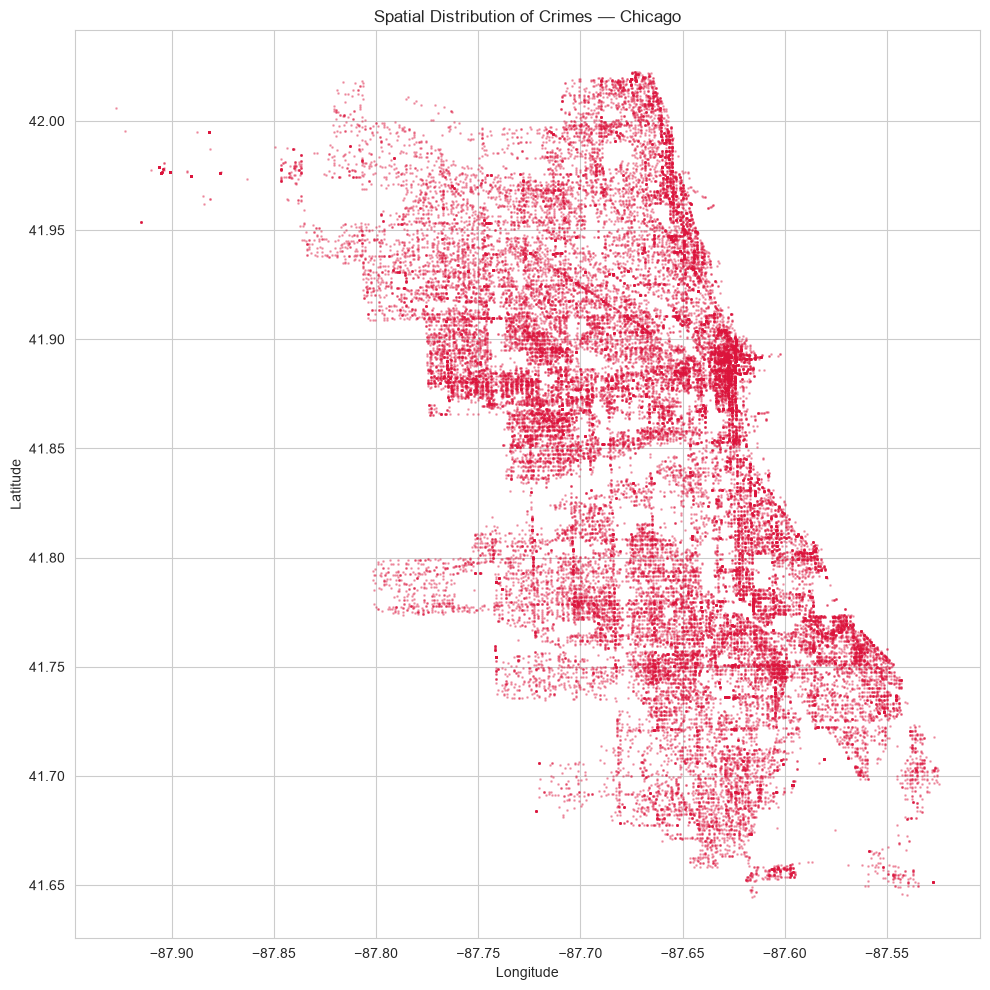

In [17]:
# ---------------- Graph 8: Spatial Scatter Map ----------------

geo_df = df.dropna(
    subset=['Latitude', 'Longitude']
).sample(
    min(50000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 10))

plt.scatter(
    geo_df['Longitude'],
    geo_df['Latitude'],
    s=1,
    alpha=0.3,
    c='crimson'
)

plt.title('Spatial Distribution of Crimes — Chicago')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/08_spatial_map.png',
    dpi=300
)

plt.show()

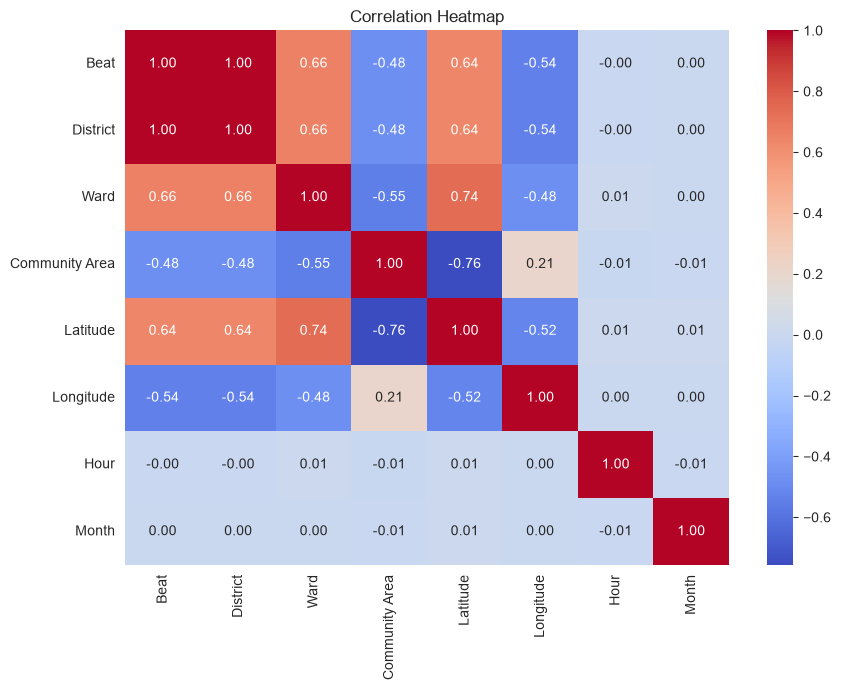

In [18]:
# ---------------- Graph 9: Correlation Heatmap ----------------

num_cols = [
    'Beat',
    'District',
    'Ward',
    'Community Area',
    'Latitude',
    'Longitude',
    'Hour',
    'Month'
]

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/09_correlation_heatmap.png',
    dpi=300
)

plt.show()

In [19]:
import os

print("All graphs saved successfully!")

print(os.listdir('../outputs/output_graphs'))

All graphs saved successfully!
['01_top_crimes.png', '03_day_of_week.png', '04_hour_of_day.png', '05_arrest_rate.png', '06_domestic_pie.png', '07_top_areas.png', '08_spatial_map.png', '09_correlation_heatmap.png']


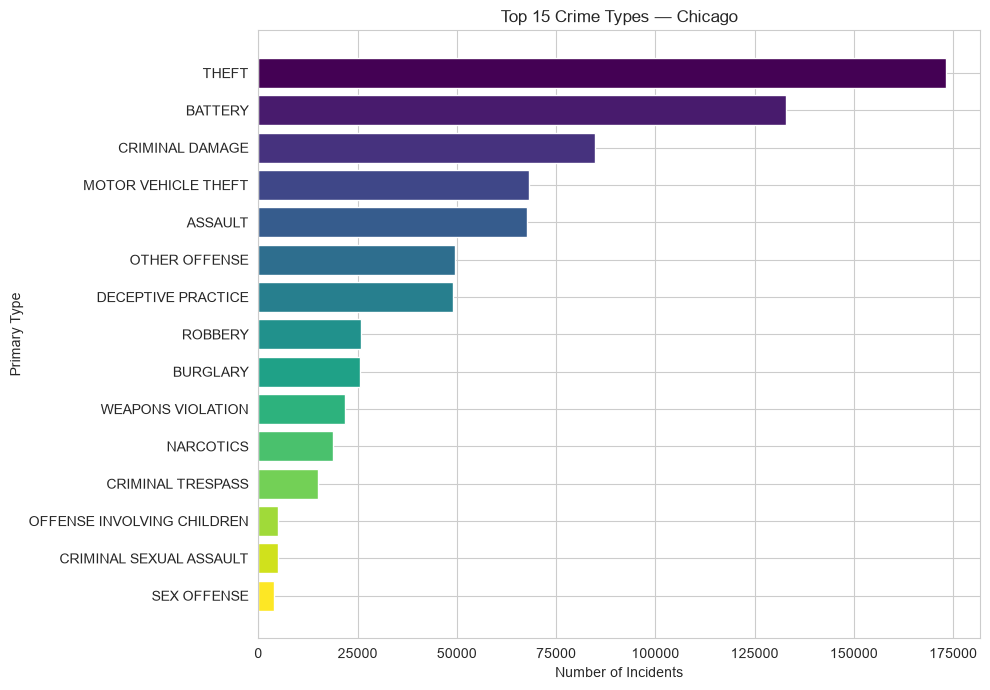

In [20]:
# ---------------- Graph 1: Top 15 Crime Types ----------------

top_crimes = df['Primary Type'].value_counts().head(15)

plt.figure(figsize=(10, 7))

# Same purple-to-green colors as your original graph
colors = plt.cm.viridis(
    np.linspace(0, 1, len(top_crimes))
)

plt.barh(
    top_crimes.index,
    top_crimes.values,
    color=colors
)

plt.title('Top 15 Crime Types — Chicago')
plt.xlabel('Number of Incidents')
plt.ylabel('Primary Type')

# Display largest crime at the top
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/01_top_crimes.png',
    dpi=300
)

plt.show()

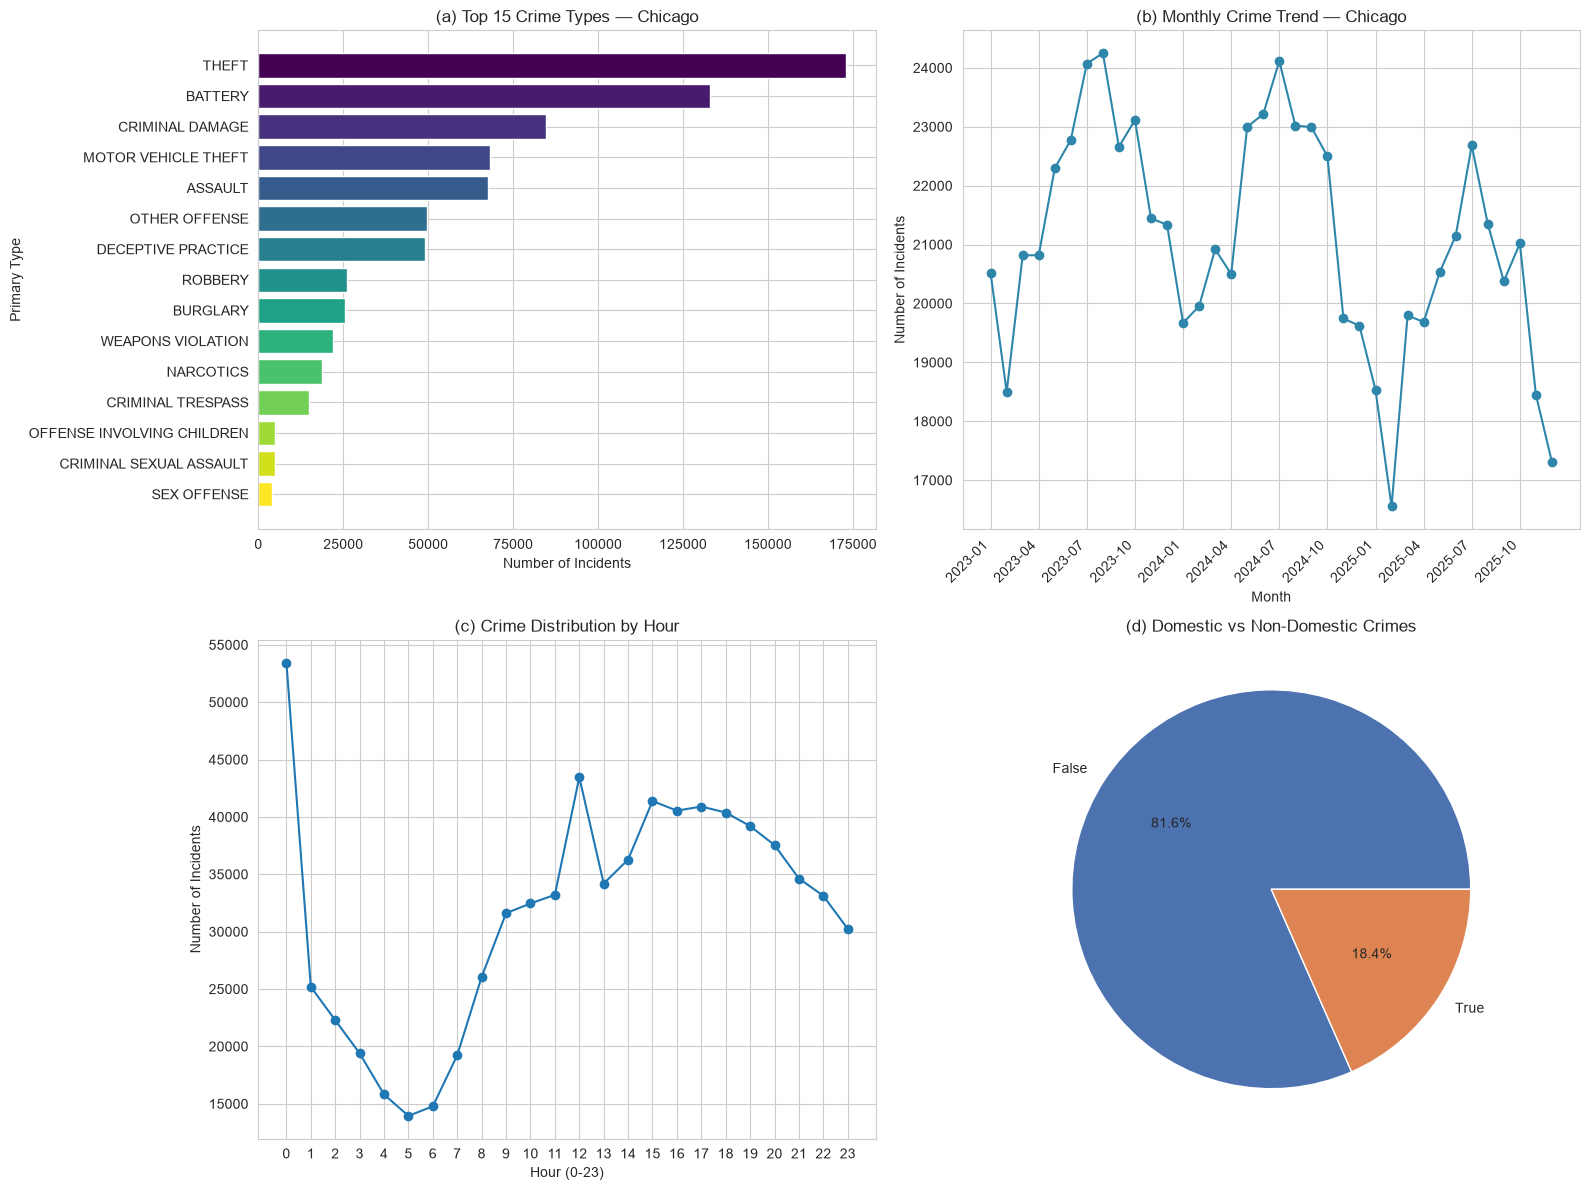

In [21]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# COMBINED FIGURE 1
# (a) Top 15 Crime Types
# (b) Monthly Crime Trend
# (c) Crime Distribution by Hour
# (d) Domestic vs Non-Domestic Distribution
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# ---------------- (a) Top 15 Crime Types ----------------

top_crimes = df['Primary Type'].value_counts().head(15)

colors = plt.cm.viridis(
    np.linspace(0, 1, len(top_crimes))
)

axes[0, 0].barh(
    top_crimes.index,
    top_crimes.values,
    color=colors
)

axes[0, 0].set_title(
    '(a) Top 15 Crime Types — Chicago'
)
axes[0, 0].set_xlabel('Number of Incidents')
axes[0, 0].set_ylabel('Primary Type')

axes[0, 0].invert_yaxis()


# ---------------- (b) Monthly Crime Trend ----------------

monthly = df.groupby(
    df['Date'].dt.to_period('M')
).size()

axes[0, 1].plot(
    monthly.index.astype(str),
    monthly.values,
    marker='o',
    color='#2E86AB'
)

axes[0, 1].set_title(
    '(b) Monthly Crime Trend — Chicago'
)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Incidents')

# Show fewer month labels
step = max(1, len(monthly) // 12)

axes[0, 1].set_xticks(
    range(0, len(monthly), step)
)

axes[0, 1].set_xticklabels(
    monthly.index.astype(str)[::step],
    rotation=45,
    ha='right'
)


# ---------------- (c) Crime Distribution by Hour ----------------

hour_counts = df['Hour'].value_counts().sort_index()

axes[1, 0].plot(
    hour_counts.index,
    hour_counts.values,
    marker='o'
)

axes[1, 0].set_title(
    '(c) Crime Distribution by Hour'
)
axes[1, 0].set_xlabel('Hour (0-23)')
axes[1, 0].set_ylabel('Number of Incidents')

axes[1, 0].set_xticks(range(0, 24))


# ---------------- (d) Domestic vs Non-Domestic ----------------

domestic_counts = df['Domestic'].value_counts()

axes[1, 1].pie(
    domestic_counts.values,
    labels=domestic_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452']
)

axes[1, 1].set_title(
    '(d) Domestic vs Non-Domestic Crimes'
)


# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/combined_crime_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

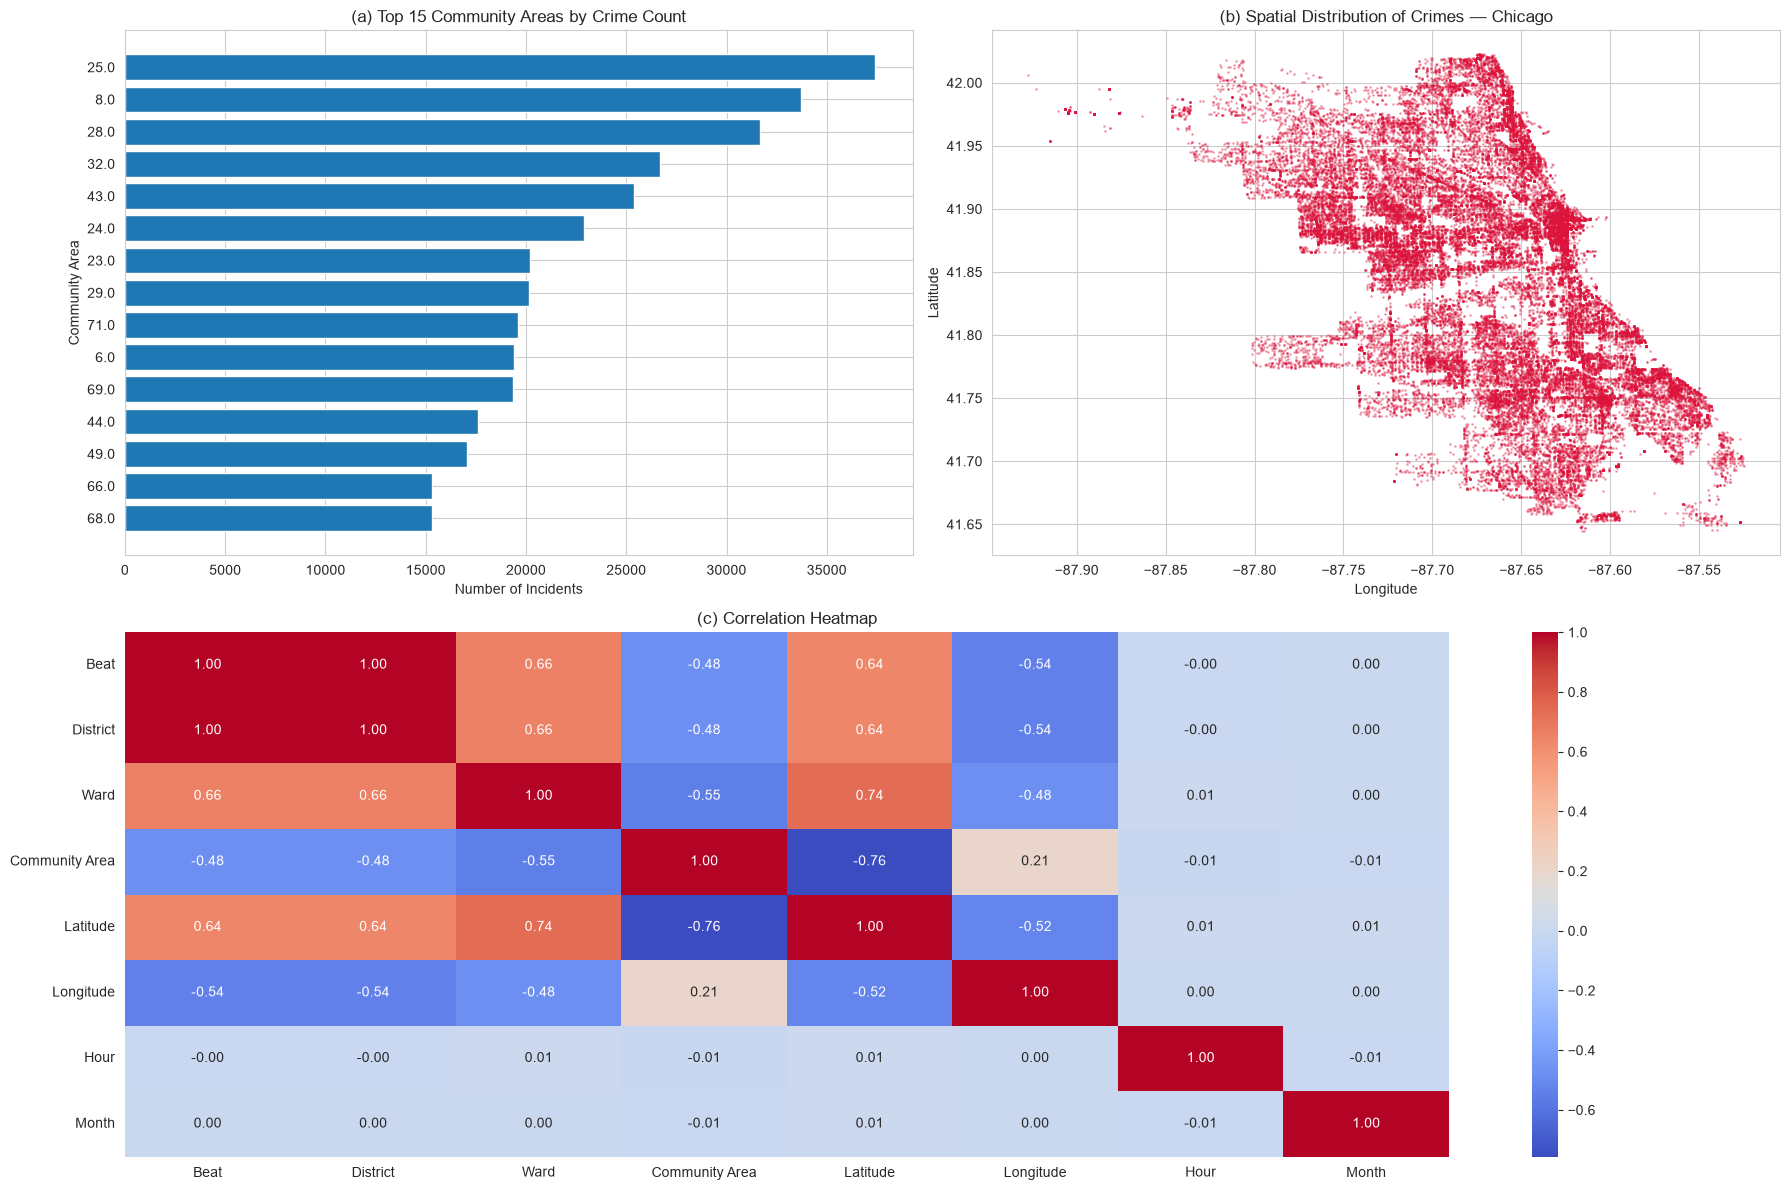

In [22]:
# ============================================================
# COMBINED FIGURE 2
# (a) Top 15 Community Areas
# (b) Spatial Distribution of Crimes
# (c) Correlation Heatmap
# ============================================================

fig = plt.figure(figsize=(18, 12))

# Create a 2x2 layout
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)


# ---------------- (a) Top 15 Community Areas ----------------

top_areas = df['Community Area'].value_counts().head(15)

ax1.barh(
    top_areas.index.astype(str),
    top_areas.values
)

ax1.set_title('(a) Top 15 Community Areas by Crime Count')
ax1.set_xlabel('Number of Incidents')
ax1.set_ylabel('Community Area')

ax1.invert_yaxis()


# ---------------- (b) Spatial Distribution of Crimes ----------------

geo_df = df.dropna(
    subset=['Latitude', 'Longitude']
).sample(
    min(50000, len(df)),
    random_state=42
)

ax2.scatter(
    geo_df['Longitude'],
    geo_df['Latitude'],
    s=1,
    alpha=0.3,
    c='crimson'
)

ax2.set_title('(b) Spatial Distribution of Crimes — Chicago')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')


# ---------------- (c) Correlation Heatmap ----------------

num_cols = [
    'Beat',
    'District',
    'Ward',
    'Community Area',
    'Latitude',
    'Longitude',
    'Hour',
    'Month'
]

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=ax3
)

ax3.set_title('(c) Correlation Heatmap')


# ---------------- Layout and Save ----------------

plt.tight_layout()

plt.savefig(
    '../outputs/output_graphs/combined_spatial_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()